In [1]:
import csv

with open("heart.csv", "r", encoding="utf-8") as file:
    reader = csv.reader(file)
    rows = list(reader)

columns = rows[0]
data = rows[1:]

print(columns)
print("Rows:", len(data))

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']
Rows: 918


In [2]:
import matplotlib.pyplot as plt

# Numerical columns

In [3]:
numeric_columns = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
    "HeartDisease"
]

print(numeric_columns)

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']


# Numerical values manually

In [4]:
numeric_data = {}

for column in numeric_columns:

    column_index = columns.index(column)

    values = []

    for row in data:

        value = row[column_index].strip()

        if value != "":
            values.append(float(value))

    numeric_data[column] = values

print(numeric_data["Age"][:10])

[40.0, 49.0, 37.0, 48.0, 54.0, 39.0, 45.0, 54.0, 37.0, 48.0]


# Minimum And Maximum manually

In [5]:
values = numeric_data["Age"]

minimum = values[0]
maximum = values[0]

for value in values:

    if value < minimum:
        minimum = value

    if value > maximum:
        maximum = value

print("Minimum:", minimum)
print("Maximum:", maximum)

Minimum: 28.0
Maximum: 77.0


# Bins manually

In [6]:
number_of_bins = 10

bin_width = (
    maximum - minimum
) / number_of_bins

print("Bin Width:", bin_width)

Bin Width: 4.9


# Bin boundaries

In [7]:
bins = []

for i in range(number_of_bins + 1):

    boundary = (
        minimum
        + i * bin_width
    )

    bins.append(boundary)

print(bins)

[28.0, 32.9, 37.8, 42.7, 47.6, 52.5, 57.400000000000006, 62.300000000000004, 67.2, 72.1, 77.0]


# Frequency manually calculate

In [8]:
frequency = []

for i in range(number_of_bins):

    lower = bins[i]
    upper = bins[i + 1]

    count = 0

    for value in values:

        if i == number_of_bins - 1:

            if lower <= value <= upper:
                count = count + 1

        else:

            if lower <= value < upper:
                count = count + 1

    frequency.append(count)

print(frequency)

[12, 37, 86, 104, 148, 201, 175, 101, 39, 15]


# Histogram

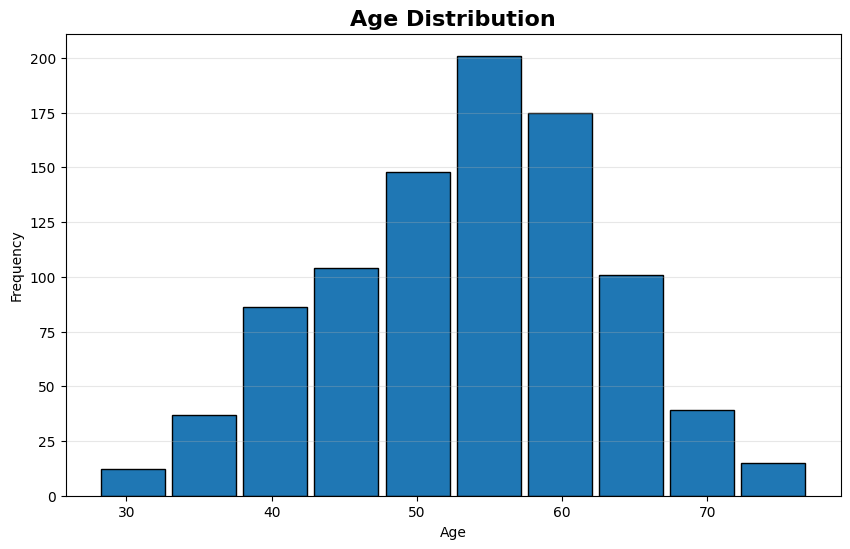

In [10]:
plt.figure(figsize=(10, 6))

plt.bar(
    bin_labels,
    frequency,
    width=bin_width * 0.9,
    edgecolor="black"
)

plt.title(
    "Age Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

# numerical features

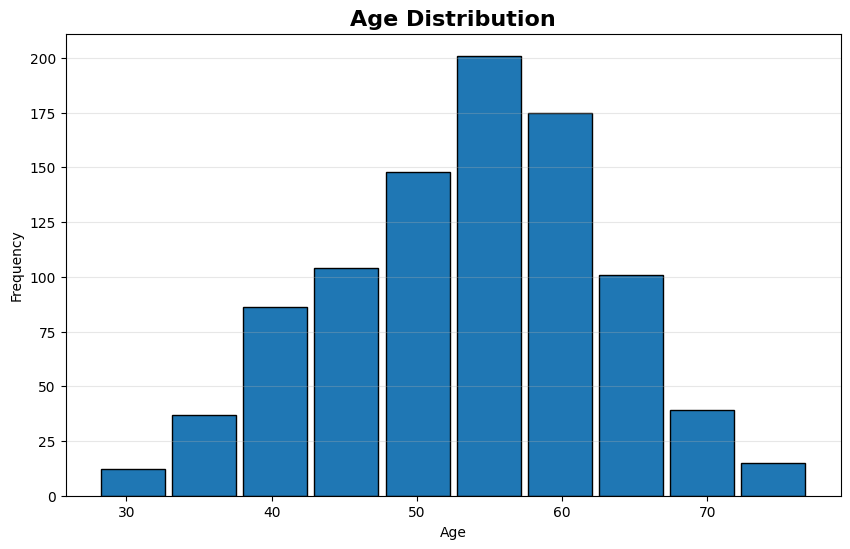

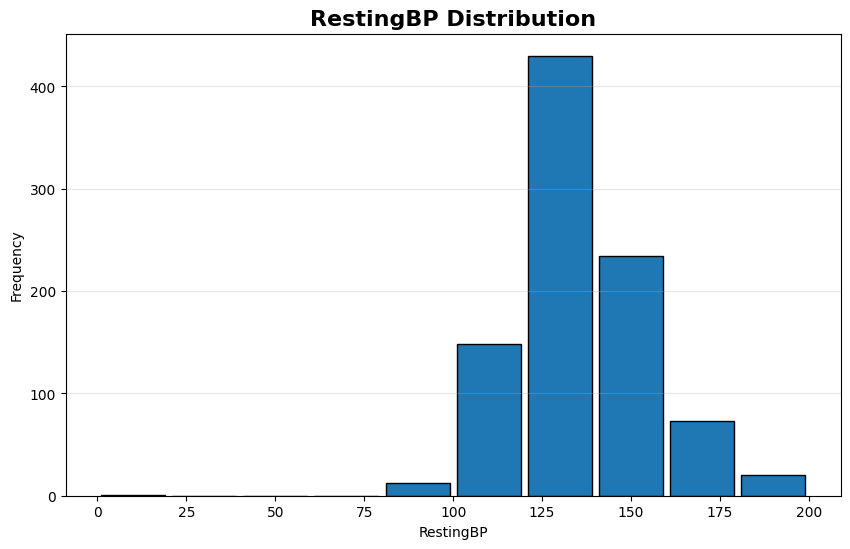

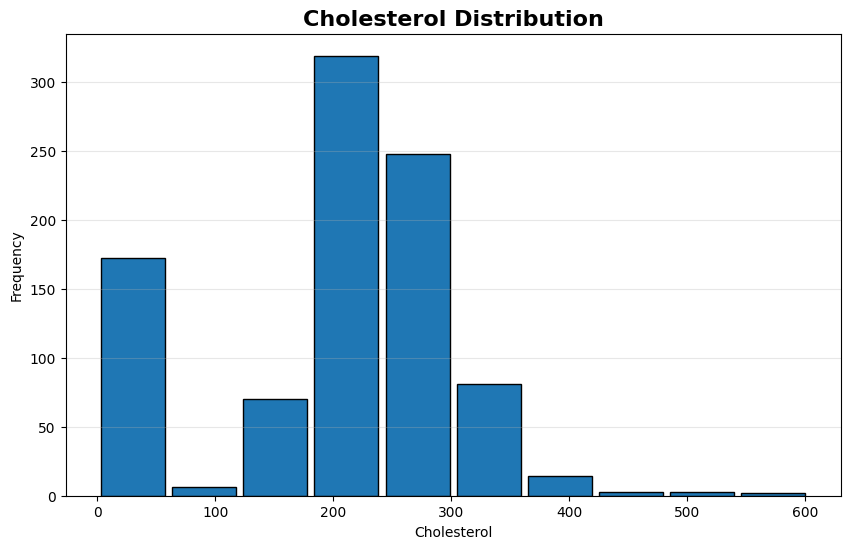

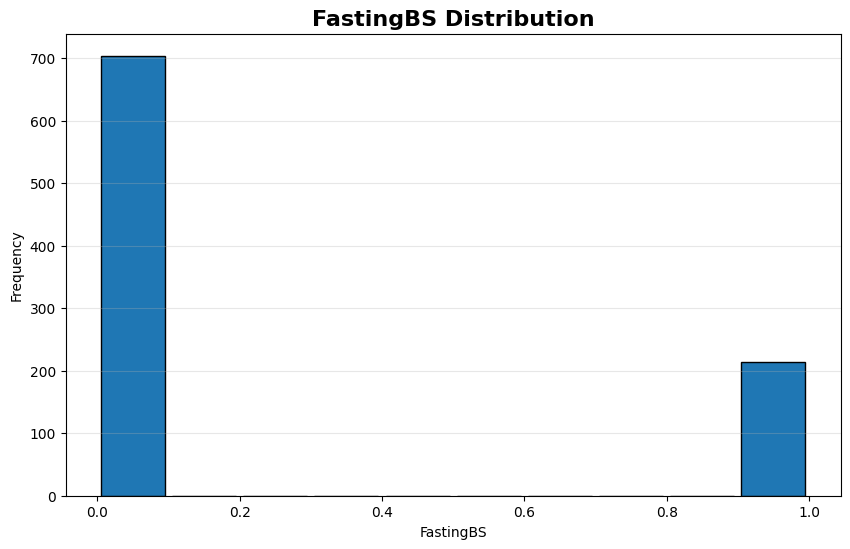

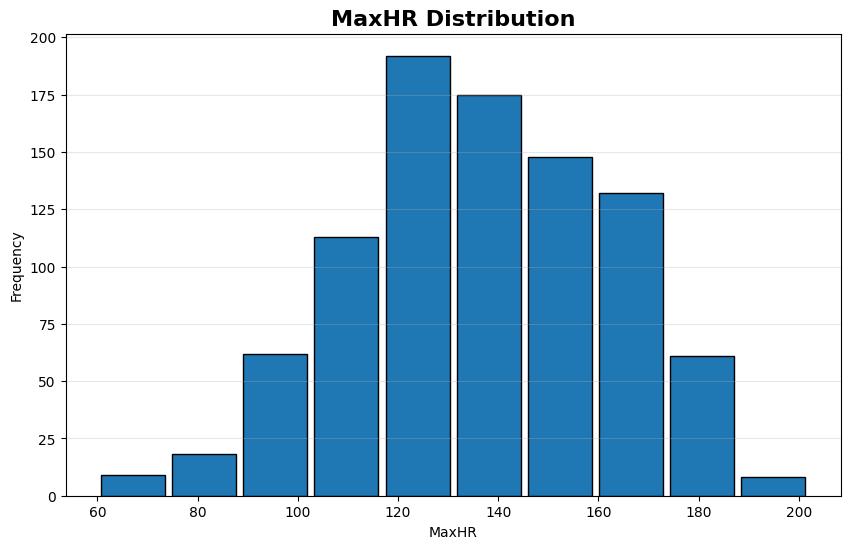

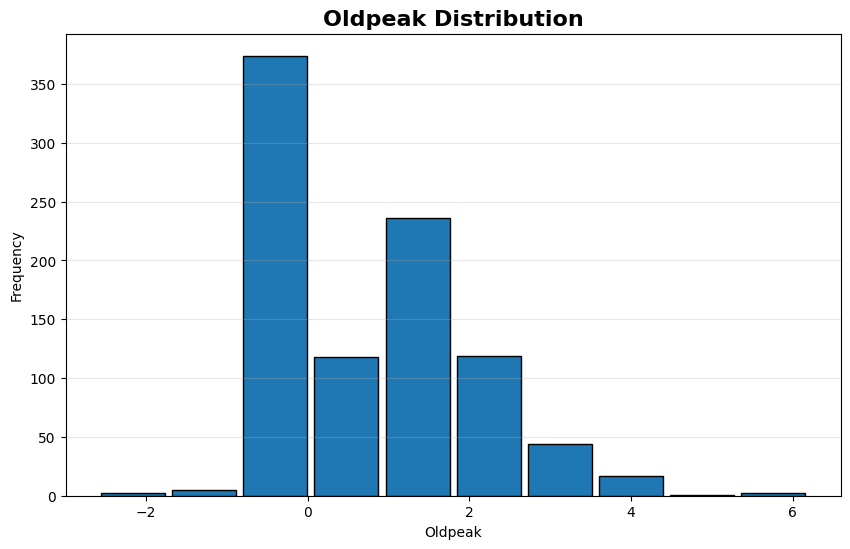

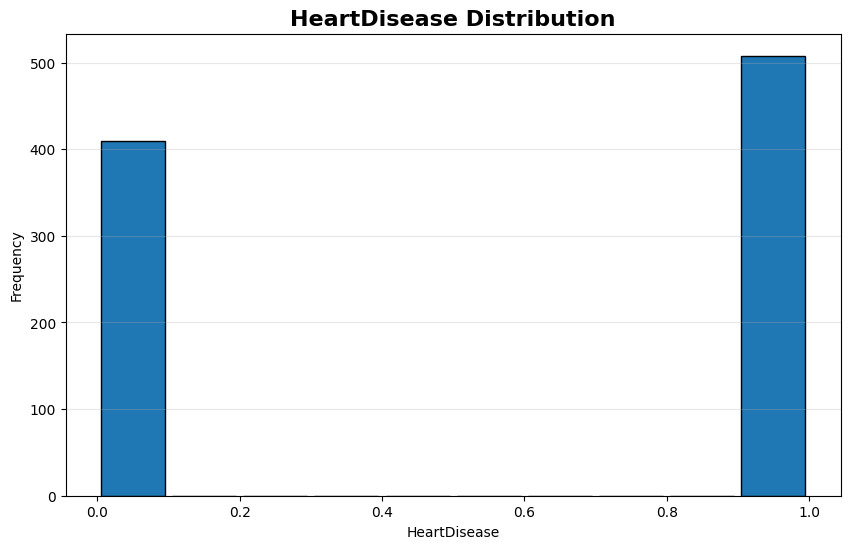

In [11]:
for column in numeric_columns:

    values = numeric_data[column]

    minimum = values[0]
    maximum = values[0]

    for value in values:

        if value < minimum:
            minimum = value

        if value > maximum:
            maximum = value

    number_of_bins = 10

    bin_width = (
        maximum - minimum
    ) / number_of_bins

    bins = []

    for i in range(number_of_bins + 1):

        boundary = (
            minimum
            + i * bin_width
        )

        bins.append(boundary)

    frequency = []

    for i in range(number_of_bins):

        lower = bins[i]
        upper = bins[i + 1]

        count = 0

        for value in values:

            if i == number_of_bins - 1:

                if lower <= value <= upper:
                    count += 1

            else:

                if lower <= value < upper:
                    count += 1

        frequency.append(count)

    bin_centers = []

    for i in range(number_of_bins):

        center = (
            bins[i] + bins[i + 1]
        ) / 2

        bin_centers.append(center)

    plt.figure(figsize=(10, 6))

    plt.bar(
        bin_centers,
        frequency,
        width=bin_width * 0.9,
        edgecolor="black"
    )

    plt.title(
        column + " Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.show()